In [3]:
from keras.models import Model
from keras.layers import Input, Dense, concatenate

input1_shape = 5
input2_shape = 6
output_shape = 2  # Assuming binary classification

# Define two input layers
input1 = Input(shape=(input1_shape,))
input2 = Input(shape=(input2_shape,))

# Concatenate the inputs
merged_inputs = concatenate([input1, input2], axis=-1)

# Additional layers after concatenation
dense1 = Dense(64, activation='relu')(merged_inputs)
dense2 = Dense(32, activation='relu')(dense1)
output = Dense(output_shape, activation='softmax')(dense2)

# Create the model
model = Model(inputs = [input1, input2], outputs = output)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 11)        │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │        768 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 2)         │         66 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,914 (11.38 KB)

 Trainable params: 2,914 (11.38 KB)

 Non-trainable params: 0 (0.00 B)

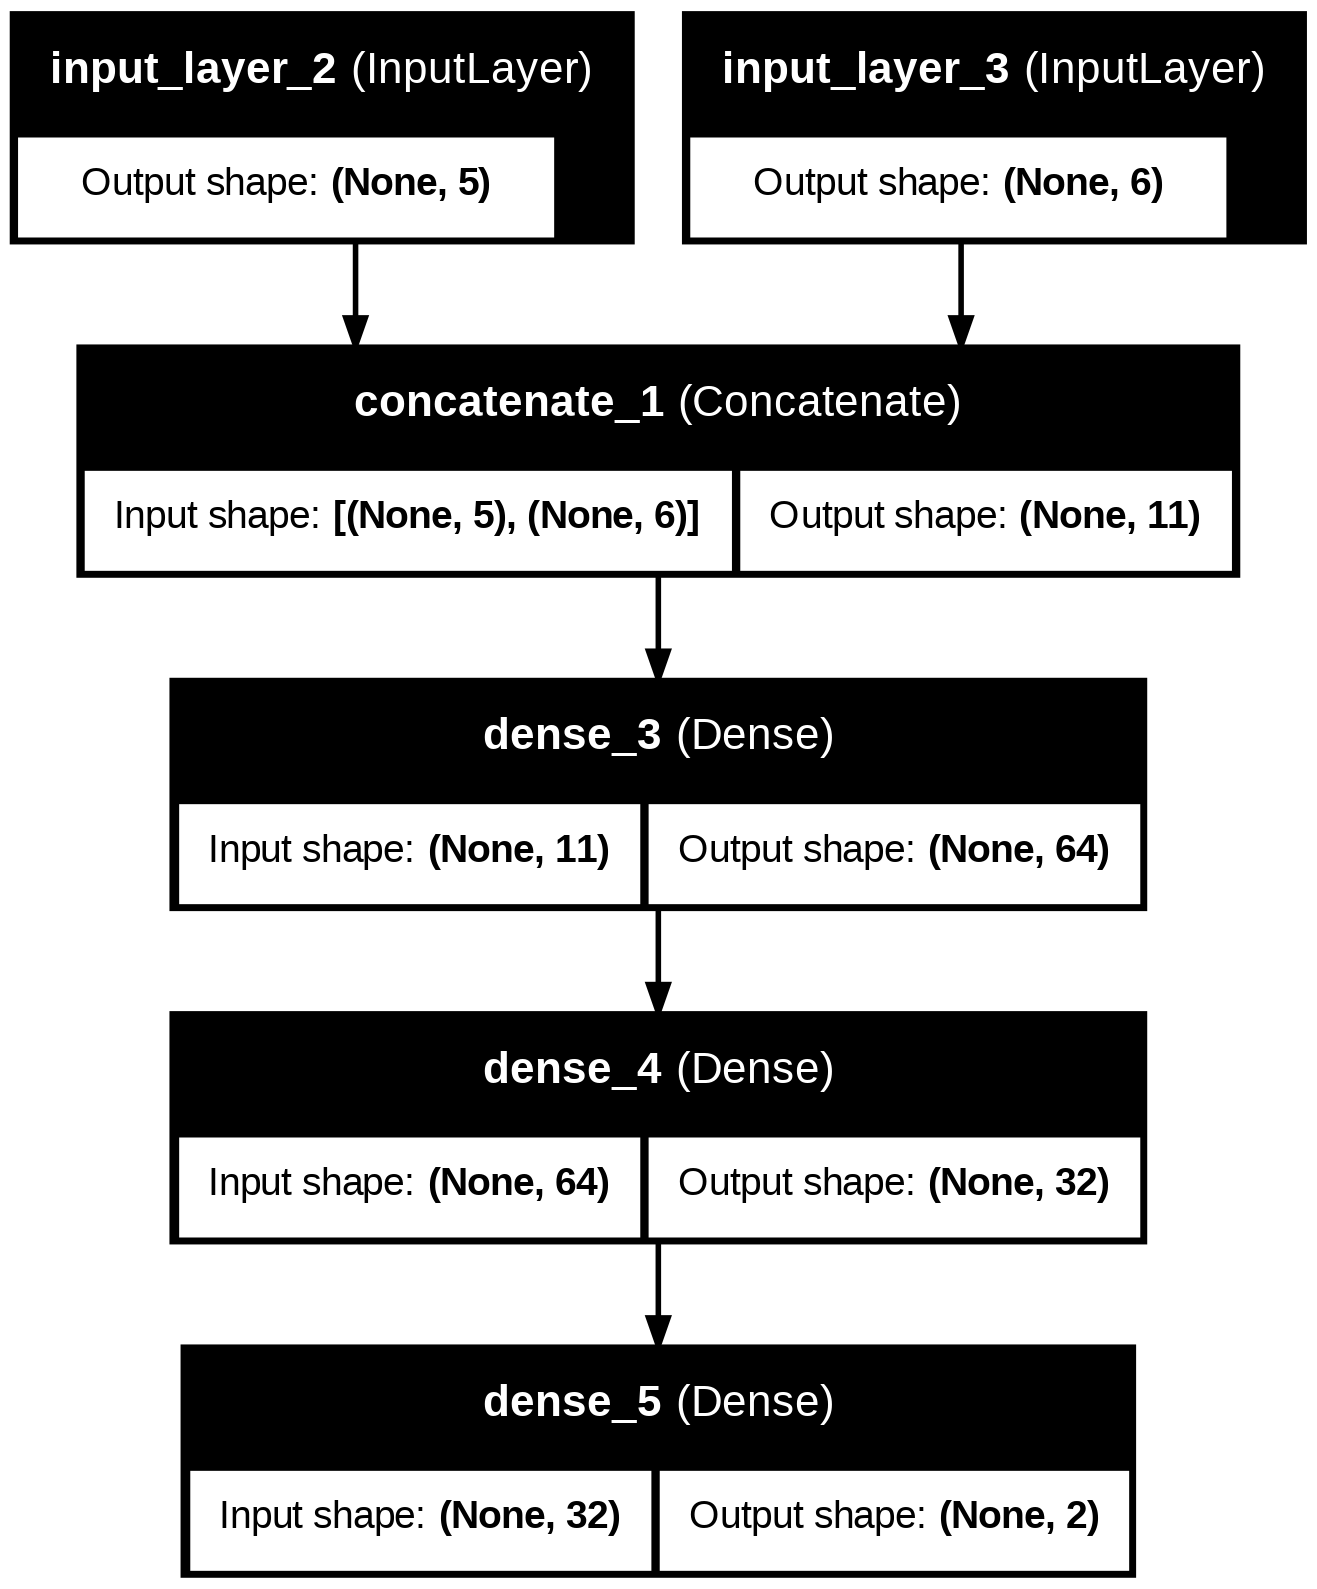

In [4]:
import tensorflow as tf
from tensorflow.keras.utils import plot_model

# Plot the model and save it to a file
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)